# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Kevin Mulder
* Username: kmulder
* Student number: S6121454
* Group (AS1, etc.): AS6

-----

In [1]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

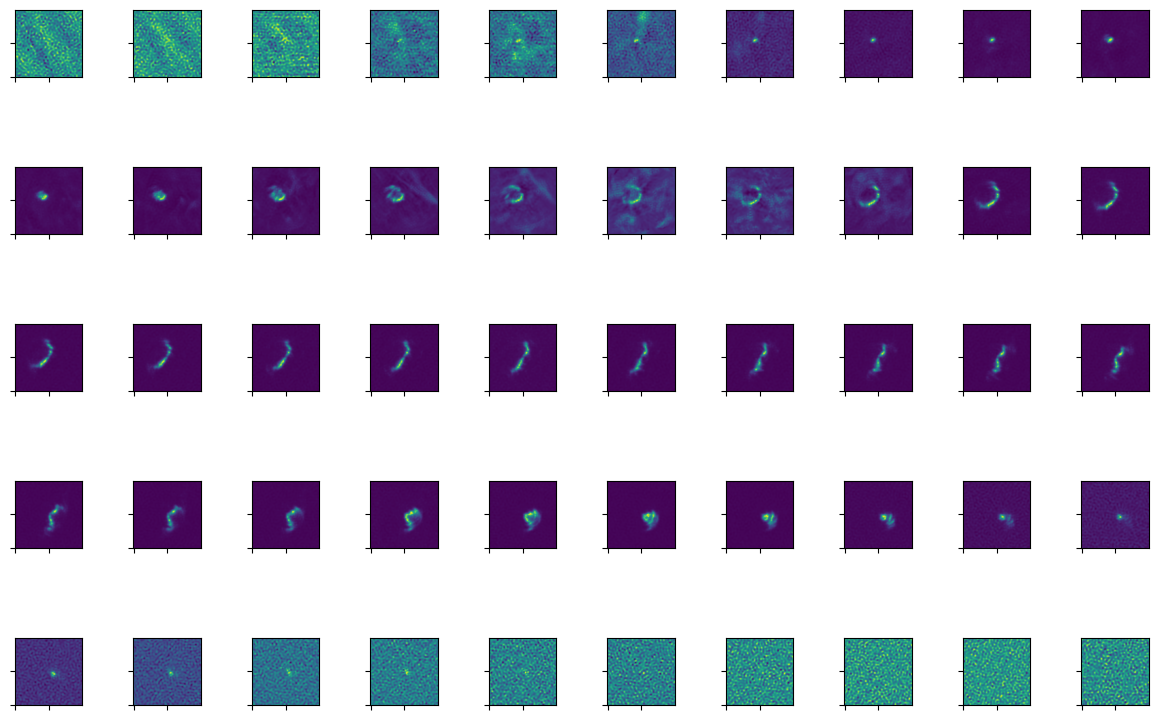

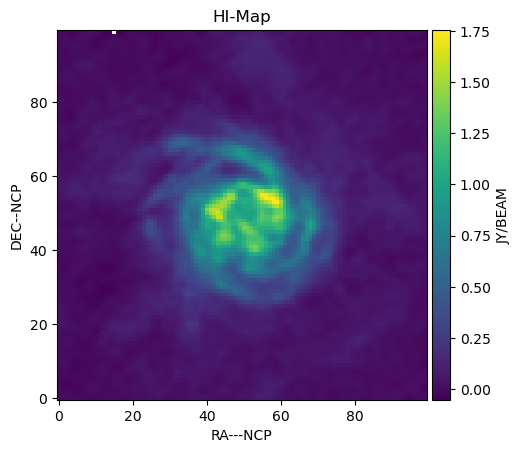

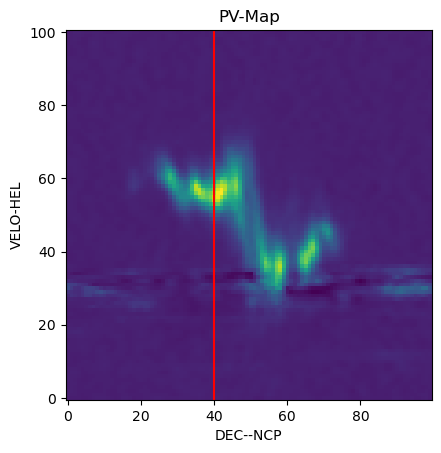

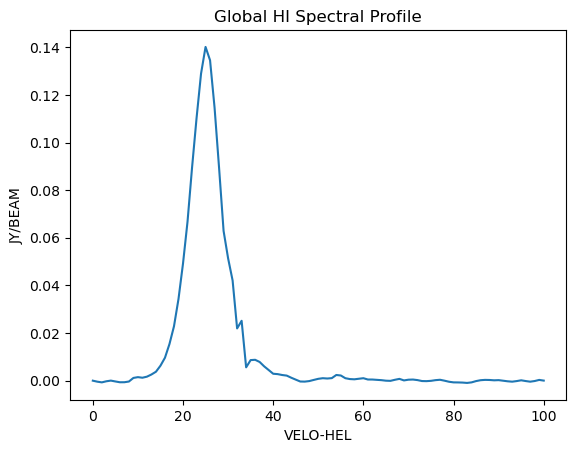

"The relation between the profile and the line is: The 1D plot shows the intensity along the line, if you'd go upwards starting at the bottom. "

In [2]:
from astropy.io import fits
from matplotlib.pyplot import *
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

hdulist = fits.open('ngc6946.fits')
data = hdulist[0].data

# Plotting mosaic
fig, frame = subplots(5, 10, figsize = (12, 8))
fig.tight_layout()

for idx, i in enumerate(range(1, 101, 2)):  # Enumerate to find index and value at that index
    row = idx // 10  # To find which row we're plotting in
    col = idx % 10  # To find which column we're plotting in
    frame[row, col].imshow(data[i, :, :], origin = 'lower', cmap = 'viridis')  # Finding data according to the index, and plotting it.
    frame[row, col].set_xticklabels([])
    frame[row, col].set_yticklabels([])
    
show()

# Plotting HI map
header = hdulist[0].header # Acessing the headers
tot_HI = np.sum(data[14:79, :, :], axis = 0)  # Adding the images on to each other

fig, frame = subplots()
image = frame.imshow(tot_HI, origin = 'lower')
frame.set_xlabel(header['CTYPE1'])  # Adding headers to axis
frame.set_ylabel(header['CTYPE2'])  
frame.set_title("HI-Map")

divider = make_axes_locatable(frame)  # For the locatable colorbar
cax = divider.append_axes('right', size = '5%', pad = 0.05)
cbar = fig.colorbar(image, cax = cax)  # Creating a colorbar 
cbar.set_label(header['BUNIT'])  # Labeling the colorbar

show()

# Making a pv-map
PV_map = data[:, :, 50]  # Slicing the data

fig, frame = subplots()
frame.imshow(PV_map, origin = 'lower')
frame.set_xlabel(header['CTYPE2'])
frame.set_ylabel(header['CTYPE3'])
frame.axvline(x=40, color = 'red')
frame.set_title("PV-Map")

show()

# Making a global HI spectral profile
HI_spectral = data[:,50,40]  # Slicing the global HI spectral profile

fig, frame = subplots()
frame.plot(HI_spectral)
frame.set_xlabel(header['CTYPE3']) # Labeling the axis
frame.set_ylabel(header['BUNIT'])
frame.set_title("Global HI Spectral Profile")

show()

"""The relation between the profile and the line is: The 1D plot shows the intensity along the line, if you'd go upwards starting at the bottom. """

In [3]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

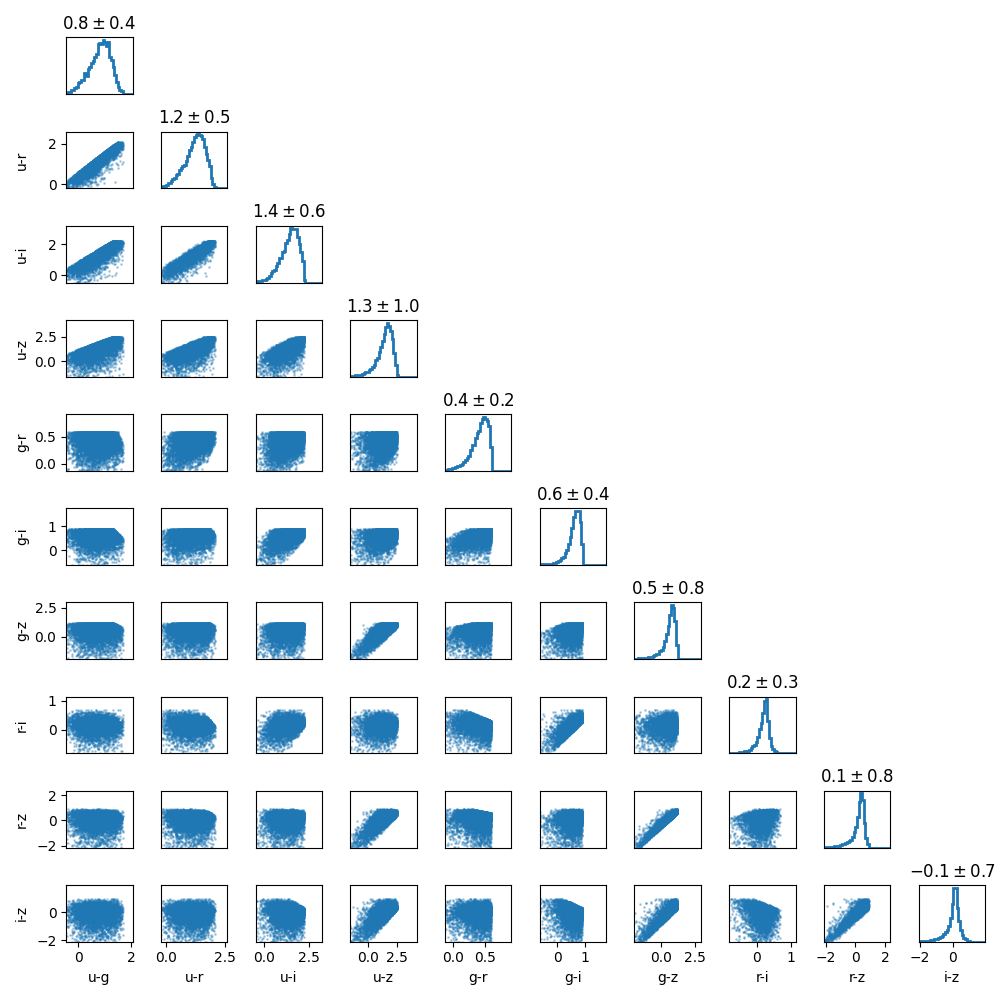
   
**Plot and answer**:

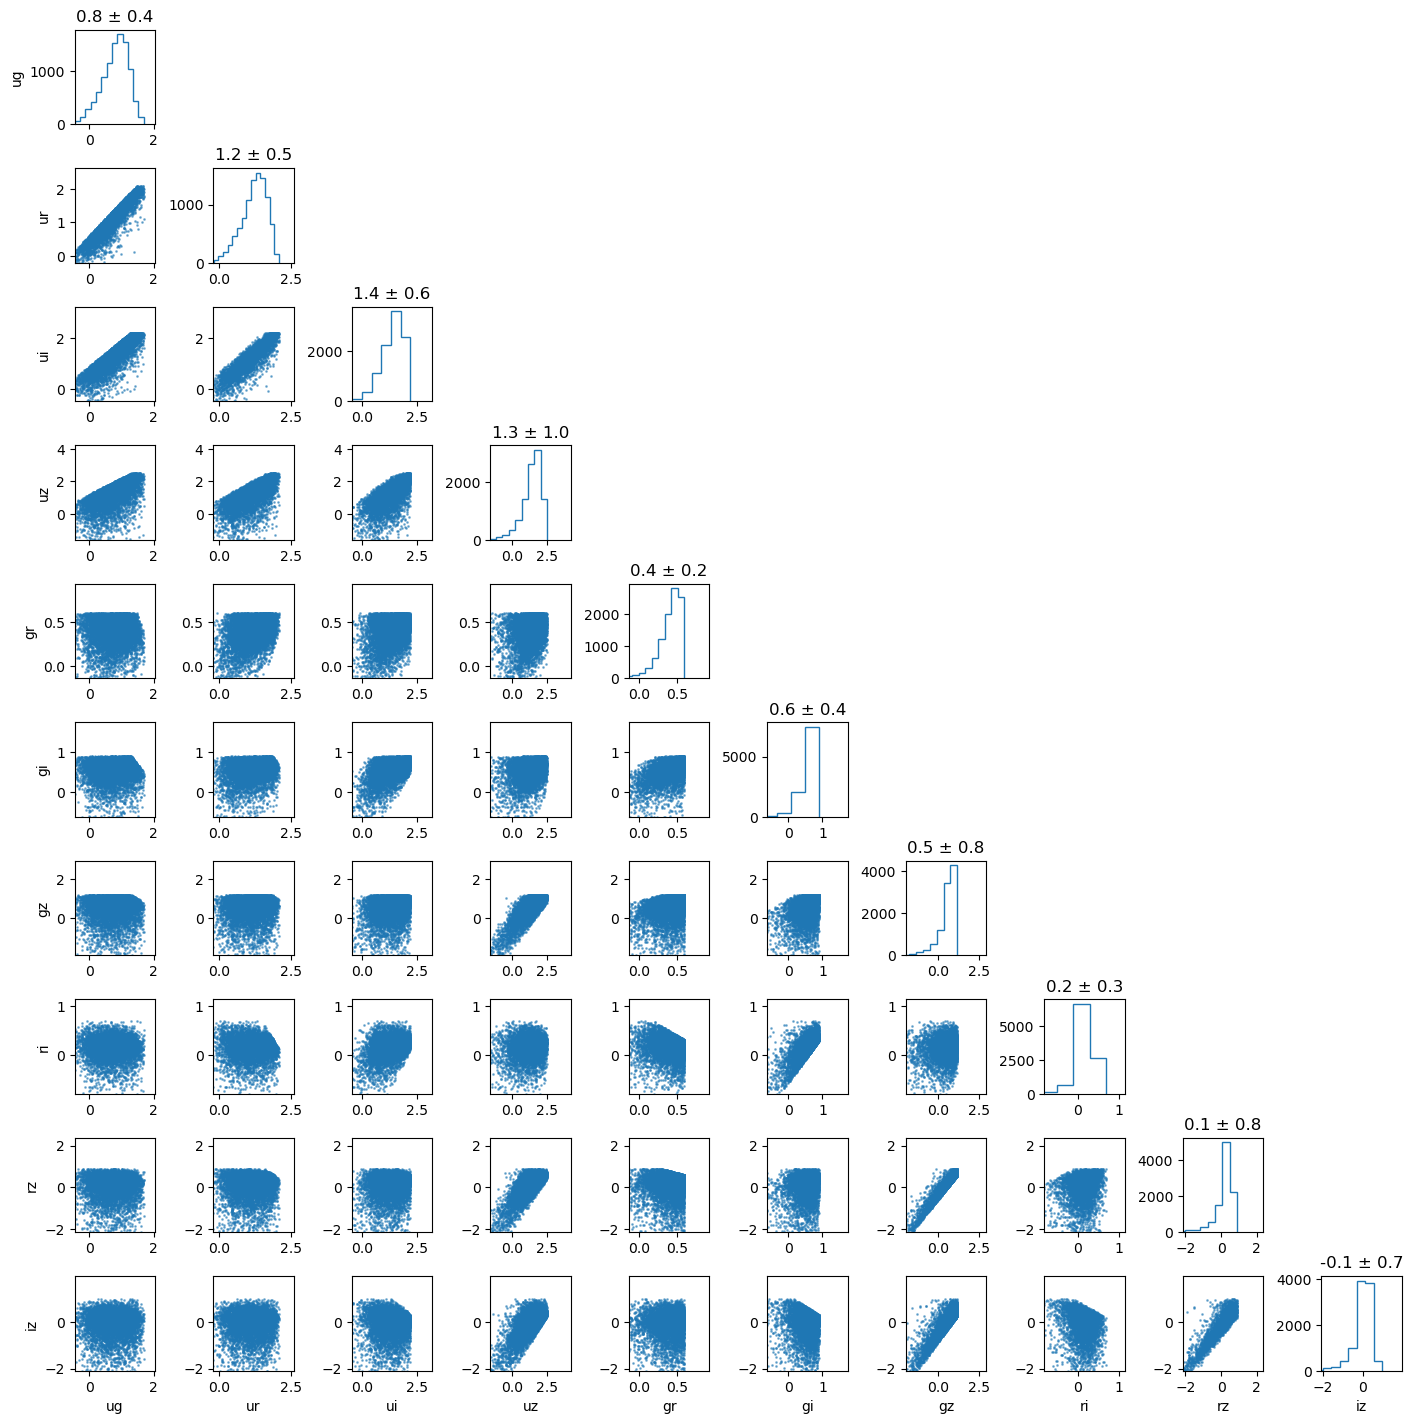

In [4]:
from astropy.io import fits
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Opening file
hdulist = fits.open('SDSS_DR17_galaxies.fits')
data = hdulist[1].data

# Converting to pandas dataframe
df1 = pd.DataFrame(data)

# Filtering all negative values
df1 = df1[df1 > 0]

# Calculating all combinations
df1['ug'] = df1['u']-df1['g']
df1['ur'] = df1['u']-df1['r']
df1['ui'] = df1['u']-df1['i']
df1['uz'] = df1['u']-df1['z']
df1['gr'] = df1['g']-df1['r']
df1['gi'] = df1['g']-df1['i']
df1['gz'] = df1['g']-df1['z']
df1['ri'] = df1['r']-df1['i']
df1['rz'] = df1['r']-df1['z']
df1['iz'] = df1['i']-df1['z']

# Creating figures
color_comb = ['ug', 'ur', 'ui', 'uz', 'gr', 'gi', 'gz', 'ri', 'rz', 'iz']  # All the different combinations
n = len(color_comb)  # Length of the amount of combinations 
fig, frame = plt.subplots(n, n, figsize = (14, 14))  # The length is used to determine the amount of plots
fig.tight_layout()

for i, ycol in enumerate(color_comb):
    for j, xcol in enumerate(color_comb):
        ax = frame[i, j]

        mu_x, sigma_x = df1[xcol].mean(), df1[xcol].std()

        if i < j:
            ax.axis("off")
            continue

        if i == j:
            ax.hist(df1[xcol].dropna(), bins=30, histtype = 'step')
            ax.set_title(f"{mu_x:.1f} ± {sigma_x:.1f}")
            ax.set_xlim(mu_x - 3*sigma_x, mu_x + 3*sigma_x)

        else:
            mu_y, sigma_y = df1[ycol].mean(), df1[ycol].std()

            ax.scatter(df1[xcol], df1[ycol], s=1, alpha=0.5)
            ax.set_xlim(mu_x - 3*sigma_x, mu_x + 3*sigma_x)
            ax.set_ylim(mu_y - 3*sigma_y, mu_y + 3*sigma_y)

        # Labeling the axis
        if i == len(color_comb) - 1:
            ax.set_xlabel(xcol)
        if j == 0:
            ax.set_ylabel(ycol)

In [5]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

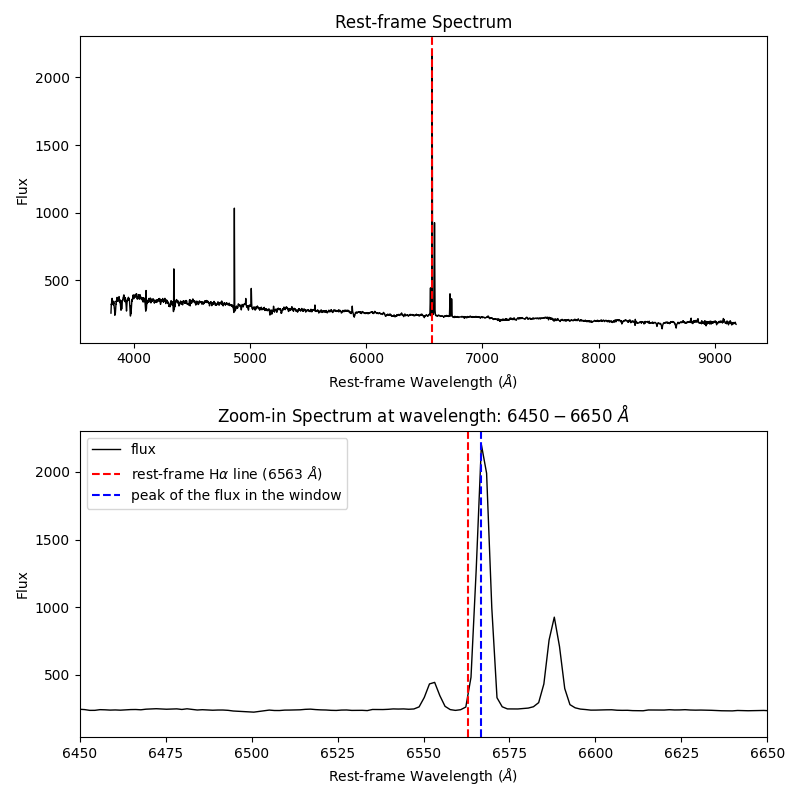

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astroquery.sdss import SDSS
import astropy.units as u
from astropy.constants import c

# Coordinates of M77
ra = 40.6696 # degrees
dec = -0.0133 # degrees
pos = SkyCoord(ra, dec, unit="deg", frame="icrs")

# Using get spectrum
spec = SDSS.query_region(pos, spectro=True, radius=10*u.arcsec)
sp = SDSS.get_spectra(matches=spec)
data = sp[1].data

# Getting the data out of the columns
flux = data['flux']
loglam = data['loglam']
wave_obs = 10**loglam 

# Calculating rest frame wavelengths
z = 0.0038
wave_rest = wave_obs / (1 + z)

h_alpha = 6563 

# --- Find peak near H-alpha ---
mask = (wave_obs > 6450) & (wave_obs < 6650)
peak_wave = wave_obs[mask][np.argmax(flux[mask])]

# Velocity from the difference between two wavelengths
v = c * (peak_wave - h_alpha) / h_alpha
print(f"The velocity = {v} km/s")

# Plotting both graphs
fig, (frame1, frame2) = plt.subplots(2, 1, figsize=(7,8))

# Top graph
frame1.plot(wave_rest, flux)
frame1.axvline(h_alpha, linestyle ='--', label ='H-alpha')
frame1.set_title("Rest-frame spectrum")
frame1.set_xlabel("Wavelength")
frame1.set_ylabel("Flux")
frame1.legend()

# Bottom graph
frame2.plot(wave_obs, flux)
frame2.set_xlim(6450, 6650)
frame2.axvline(h_alpha*(1+z), linestyle = '--', label ='H-alpha')
frame2.axvline(peak_wave, linestyle = ':', label = 'Peak')
frame2.set_title("Zoomed spectrum")
frame2.set_xlabel("Wavelength")
frame2.set_ylabel("Flux")
frame2.legend()

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

Filename: /Users/users/kmulder/PROGNUM-repo/Task6/20210422_Li_.00000066.FIT
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      44   (3072, 2048)   int16 (rescales to uint16)   

 ===> Number type: uint16


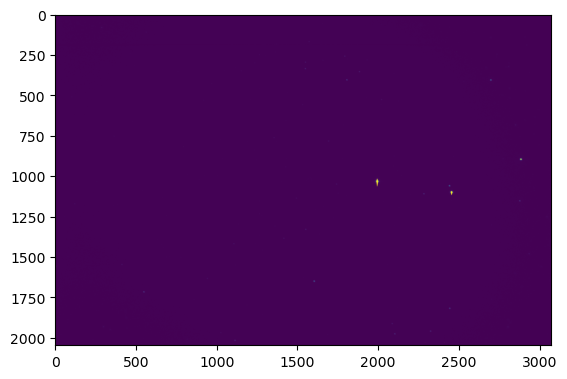

In [7]:
from astropy.io import fits
import os
from pathlib import Path
from matplotlib.pyplot import subplots, show

home = Path.home()
datapath = Path("PROGNUM-repo/Task6/20210422_Li_.00000066.FIT")
path = home / datapath

hdulist = fits.open(path)
hdulist.info()
BO_data = hdulist[0].data

if 'int' in str(BO_data.dtype):
    image_data = BO_data.astype('float')
print("\n ===> Number type:", BO_data.dtype)

fig, frame = subplots()
frame.imshow(BO_data)
show()

# Function imdisplay
def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

In [8]:
from pathlib import Path
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval
from matplotlib.pyplot import figure, show
from astropy.io import fits
from math import ceil

datadir = '/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/'
excludes = ['BIAS', 'FLAT', 'DARK']  

path = Path(datadir)
filepaths = []
for filepath in path.iterdir():
    if filepath.suffix.lower() in ['.fits', '.fit', '.fts']:
        if not any(ext in filepath.name for ext in excludes):
            filepaths.append(filepath)


for f in filepaths[:5]:
    print(f.name)


def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)

fig = figure(figsize=(8,6), tight_layout=True)
count = 1
ncols = 5
nrows = ceil(len(filepaths)/ncols)
for i, filepath in enumerate(filepaths):
    hdulist = fits.open(filepath)
    ax = fig.add_subplot(nrows, ncols, count)
    ax.axis('off')
    imdisplay(hdulist[0].data, ax, scale='power', power=3, cmap='twilight')
    ax.set_title(f"{i}: {filepath.name}", fontsize=7)
    count += 1
    hdulist.close()
show()

101212_Li_.00000074.FIT
101212_Li_.00000073.FIT
101212_Li_.00000046.FIT
101212_Li_.00000097.FIT
101212_Li_.00000041.FIT


/Software/users/modules/9/software/anaconda3/2025.06/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


KeyboardInterrupt: 

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")